<a href="https://colab.research.google.com/github/BHVPhuc/Lab03_AI/blob/feature%2Ffood/food.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Food-MNIST Dataset Analysis
This notebook fulfills the requirements for analyzing the Food-MNIST dataset, including dataset preparation, building a Decision Tree classifier, tuning hyperparameters, building a Neural Network classifier, and performing performance evaluation and comparison.

In [ ]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

def stratified_split(X, y, val_size=0.2, random_state=42):
    """Chia dữ liệu train/val theo phân tầng."""
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=val_size, stratify=y, random_state=random_state, shuffle=True
    )
    return X_train, y_train, X_val, y_val

def plot_class_distribution(y, title="Class Distribution", save_path=None, figsize=(8,5)):
    """Vẽ phân phối nhãn cho tập dữ liệu."""
    plt.figure(figsize=figsize)
    sns.countplot(x=y, palette='viridis')
    plt.title(title, fontsize=14)
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Đã lưu biểu đồ vào {save_path}")
    plt.show()

def evaluate_model(model, X_test, y_test, model_name="Model", save_cm_path=None, class_names=None):
    """Đánh giá mô hình, in classification report và vẽ confusion matrix."""
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"\n{'='*50}")
    print(f"📊 KẾT QUẢ ĐÁNH GIÁ - {model_name}")
    print(f"{'='*50}")
    print(f"Độ chính xác (Accuracy): {accuracy:.4f}")
    print("\n📋 Classification Report:")
    print(classification_report(y_test, y_pred, target_names=class_names))
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    if save_cm_path:
        plt.savefig(save_cm_path, dpi=150, bbox_inches='tight')
        print(f"Đã lưu confusion matrix vào {save_cm_path}")
    plt.show()
    return y_pred, accuracy

# Đảm bảo thư mục figures tồn tại
os.makedirs('../figures', exist_ok=True)

### 2.1 Preparing the dataset
Download dataset and flatten images to 1D arrays for scikit-learn models.

In [3]:
!git clone https://github.com/srohit0/food_mnist.git

Cloning into 'food_mnist'...
remote: Enumerating objects: 5094, done.
remote: Total 5094 (delta 0), reused 0 (delta 0), pack-reused 5094 (from 1)
Receiving objects: 100% (5094/5094), 239.57 MiB | 12.71 MiB/s, done.
Resolving deltas: 100% (37/37), done.
Updating files: 100% (5015/5015), done.


In [4]:
def load_food_images_from_meta(base_repo_path, split='train', target_size=(64, 64)):
    """Loads images based on meta train/test split files."""
    X, y = [], []
    meta_file = os.path.join(base_repo_path, 'meta', f'{split}.txt')
    images_dir = os.path.join(base_repo_path, 'images')

    with open(meta_file, 'r') as f:
        lines = f.read().splitlines()

    # Extract valid class names by looking at subdirectories in images/
    class_names = sorted([d for d in os.listdir(images_dir) if os.path.isdir(os.path.join(images_dir, d))])
    class_to_idx = {name: idx for idx, name in enumerate(class_names)}

    for line in lines:
        if not line: continue
        class_name = line.split('/')[0]
        label = class_to_idx.get(class_name)
        if label is None: continue

        # Append .jpg as defined in the repo
        img_path = os.path.join(images_dir, f"{line}.jpg")

        try:
            # Open image, resize, convert to RGB, and flatten to 1D array
            img = Image.open(img_path).convert('RGB')
            img = img.resize(target_size)
            img_array = np.array(img).flatten()
            X.append(img_array)
            y.append(label)
        except Exception as e:
            pass

    return np.array(X), np.array(y), class_names

print("Loading training data...")
X_train_full, y_train_full, class_names = load_food_images_from_meta('food_mnist', split='train')
print("Loading test data...")
X_test, y_test, _ = load_food_images_from_meta('food_mnist', split='test')

print(f"Full Train shape: {X_train_full.shape}")
print(f"Test shape: {X_test.shape}")

Loading training data...
Loading test data...
Full Train shape: (3750, 12288)
Test shape: (1250, 12288)


Train set size: 3000
Validation set size: 750


/content/Lab03_AI/utils/helpers.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='viridis')


Đã lưu biểu đồ vào ../figures/food_train_dist.png


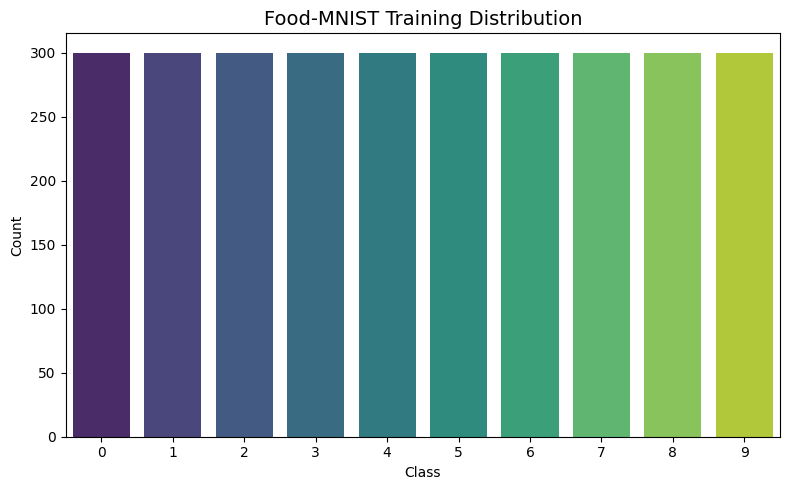

/content/Lab03_AI/utils/helpers.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='viridis')


Đã lưu biểu đồ vào ../figures/food_val_dist.png


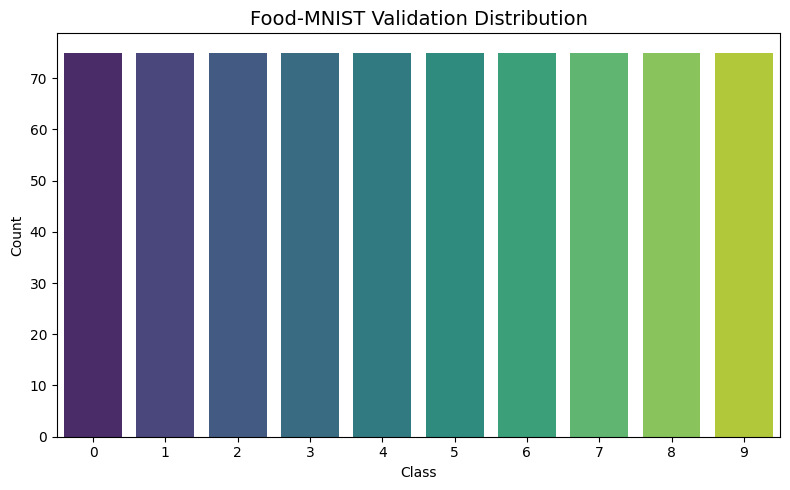

In [5]:
# Chia tập Train_full thành Train (80%) và Validation (20%) bằng stratified split
X_train, y_train, X_val, y_val = stratified_split(X_train_full, y_train_full, val_size=0.2, random_state=42)

print(f"Train set size: {X_train.shape[0]}")
print(f"Validation set size: {X_val.shape[0]}")

# Visualize
plot_class_distribution(y_train, title="Food-MNIST Training Distribution", save_path="../figures/food_train_dist.png")
plot_class_distribution(y_val, title="Food-MNIST Validation Distribution", save_path="../figures/food_val_dist.png")

### 2.2 Building the decision tree classifier

Validation accuracy of base Decision Tree: 0.1707


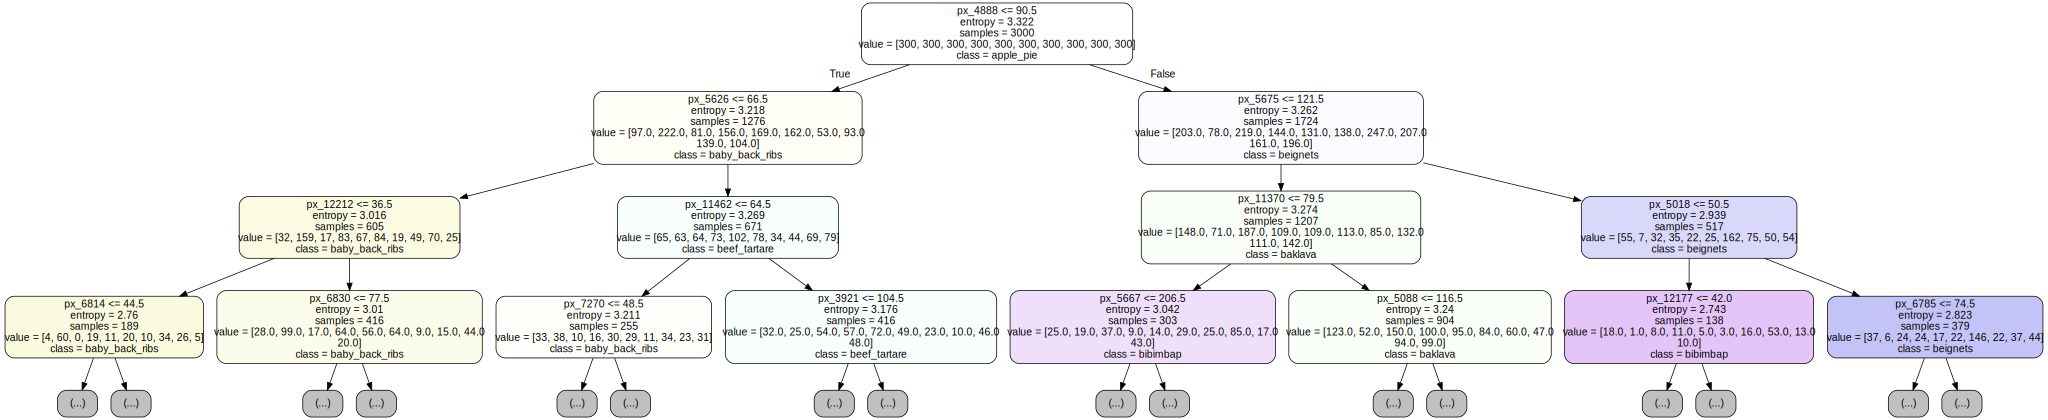

In [6]:
from sklearn.tree import DecisionTreeClassifier, export_graphviz
import graphviz

# Train using Information Gain (entropy)
dt_base = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_base.fit(X_train, y_train)

print(f"Validation accuracy of base Decision Tree: {dt_base.score(X_val, y_val):.4f}")

# Visualize the tree (limiting depth to 3 so it's readable)
dot_data = export_graphviz(dt_base, max_depth=3, feature_names=[f"px_{i}" for i in range(X_train.shape[1])],
                           class_names=class_names, filled=True, rounded=True)
graph = graphviz.Source(dot_data)
graph.render("../figures/food_tree", format="png", cleanup=True)
graph

### 2.3 Hyperparameter tuning for decision tree classifier

In [7]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Use RandomizedSearchCV to save time
random_search = RandomizedSearchCV(
    DecisionTreeClassifier(criterion='entropy', random_state=42),
    param_dist, n_iter=10, cv=3, random_state=42, n_jobs=-1, verbose=2
)
random_search.fit(X_train, y_train)

best_dt = random_search.best_estimator_
print("Best params:", random_search.best_params_)
print(f"Validation Accuracy (Tuned): {best_dt.score(X_val, y_val):.4f}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best params: {'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 10}
Validation Accuracy (Tuned): 0.1600


### 2.4 Building the neural network classifier

In [8]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128),  # 2 hidden layers due to complexity of RGB images
    activation='relu',
    solver='adam',
    max_iter=300,
    early_stopping=True,
    random_state=42,
    verbose=True
)

mlp.fit(X_train, y_train)
print(f"MLP Validation Accuracy: {mlp.score(X_val, y_val):.4f}")

Iteration 1, loss = 32.43470899
Validation score: 0.116667
Iteration 2, loss = 30.53179770
Validation score: 0.136667
Iteration 3, loss = 29.20456511
Validation score: 0.166667
Iteration 4, loss = 28.55104011
Validation score: 0.136667
Iteration 5, loss = 28.24709294
Validation score: 0.123333
Iteration 6, loss = 28.59014620
Validation score: 0.186667
Iteration 7, loss = 26.94839669
Validation score: 0.173333
Iteration 8, loss = 26.81217061
Validation score: 0.176667
Iteration 9, loss = 26.22173457
Validation score: 0.186667
Iteration 10, loss = 25.63579852
Validation score: 0.116667
Iteration 11, loss = 27.18237045
Validation score: 0.170000
Iteration 12, loss = 26.38943263
Validation score: 0.143333
Iteration 13, loss = 21.71635077
Validation score: 0.160000
Iteration 14, loss = 22.17012197
Validation score: 0.190000
Iteration 15, loss = 23.23309311
Validation score: 0.116667
Iteration 16, loss = 28.60377407
Validation score: 0.173333
Iteration 17, loss = 24.49471132
Validation score

### 2.5 Performance evaluation and comparison

=== DECISION TREE (TUNED) ===

📊 KẾT QUẢ ĐÁNH GIÁ - Food DT
Độ chính xác (Accuracy): 0.1768

📋 Classification Report:
                   precision    recall  f1-score   support

        apple_pie       0.12      0.21      0.15       125
   baby_back_ribs       0.22      0.19      0.20       125
          baklava       0.13      0.15      0.14       125
   beef_carpaccio       0.19      0.17      0.18       125
     beef_tartare       0.11      0.09      0.10       125
       beet_salad       0.16      0.14      0.15       125
         beignets       0.28      0.26      0.27       125
         bibimbap       0.36      0.31      0.33       125
    bread_pudding       0.17      0.13      0.15       125
breakfast_burrito       0.12      0.13      0.12       125

         accuracy                           0.18      1250
        macro avg       0.18      0.18      0.18      1250
     weighted avg       0.18      0.18      0.18      1250

Đã lưu confusion matrix vào ../figures/food_dt_cm.png

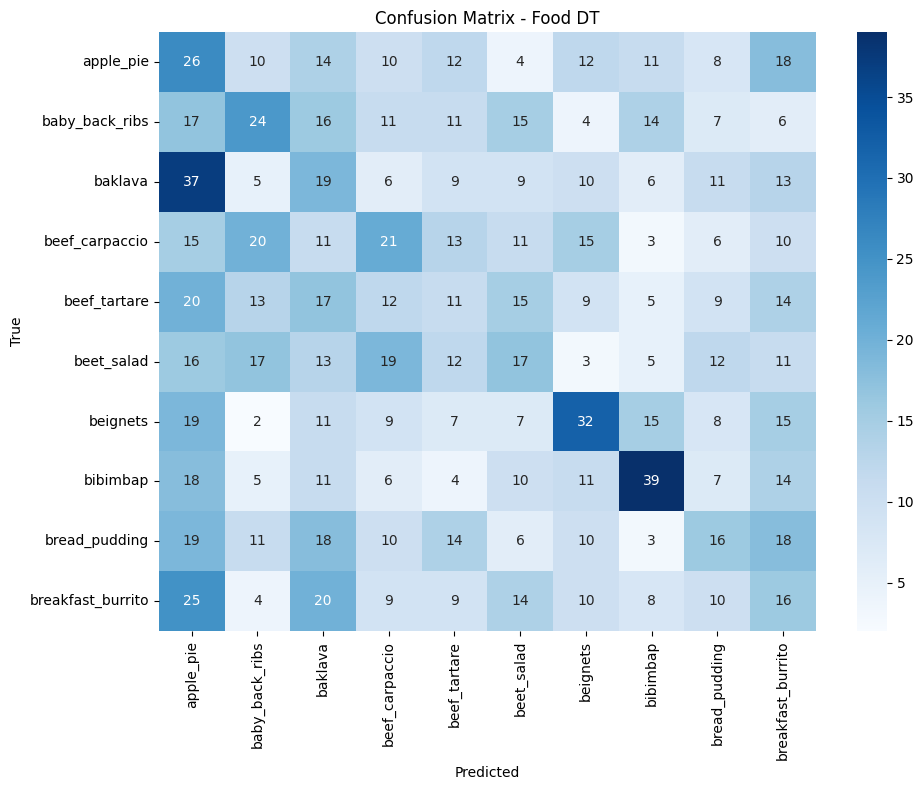

=== NEURAL NETWORK ===

📊 KẾT QUẢ ĐÁNH GIÁ - Food MLP
Độ chính xác (Accuracy): 0.2240

📋 Classification Report:
                   precision    recall  f1-score   support

        apple_pie       0.15      0.57      0.24       125
   baby_back_ribs       0.25      0.10      0.14       125
          baklava       0.00      0.00      0.00       125
   beef_carpaccio       0.25      0.56      0.35       125
     beef_tartare       0.09      0.03      0.05       125
       beet_salad       0.00      0.00      0.00       125
         beignets       0.29      0.85      0.43       125
         bibimbap       0.67      0.10      0.17       125
    bread_pudding       0.22      0.02      0.03       125
breakfast_burrito       0.19      0.02      0.04       125

         accuracy                           0.22      1250
        macro avg       0.21      0.22      0.14      1250
     weighted avg       0.21      0.22      0.14      1250



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Đã lưu confusion matrix vào ../figures/food_mlp_cm.png


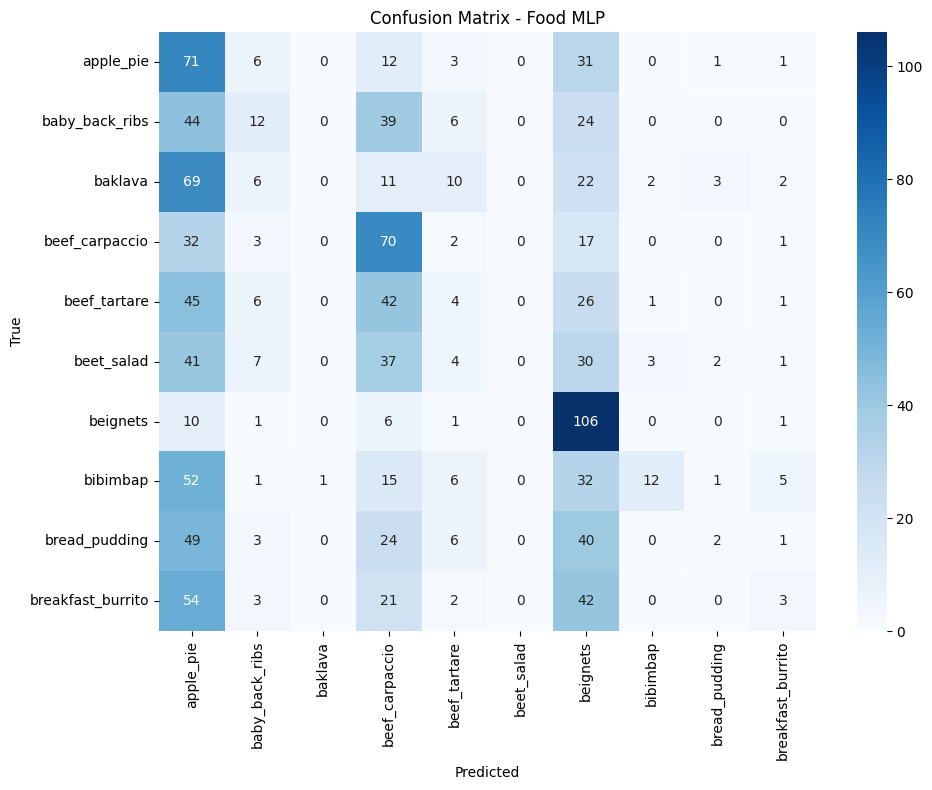

In [9]:
print("=== DECISION TREE (TUNED) ===")
_, dt_acc = evaluate_model(best_dt, X_test, y_test, model_name="Food DT",
                           save_cm_path="../figures/food_dt_cm.png", class_names=class_names)

print("=== NEURAL NETWORK ===")
_, mlp_acc = evaluate_model(mlp, X_test, y_test, model_name="Food MLP",
                            save_cm_path="../figures/food_mlp_cm.png", class_names=class_names)